In [24]:
# imports
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import geopandas as gpd
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
final_data = Path.cwd().parent.joinpath('processed_data', 'final_dataset.csv')

**Variables in final_dataset.csv**

- `geo_id`, `county_name`: unique ID of counties and names (names might be duplicated) 

- `population`: population of county in 2025 (released in March 2026 by Census)

- `median_household_income`: 

- `housing_units`: 

- `total_energy_consumption_mwh`: total energy consumption of the county in 2024 in MWh	

- `data_centers_count`: number of data centers in the county 

- `sfha_area`: severe flood hazard area (SFHA) in the county

- `pct_sfha`: proportion of the county that is SFHA

- `lake_count`: number of lakes that intersectsthe county

- `total_lake_area`: total lakes area in the county

- `avg_vol`: average volume of lakes in the county 

- `avg_depth`: average depth of lakes in the county 

- `avg_discharge`: average discharge of lakes in the county (discharge = the volume of water flowing out of it over a specific period)

- `dist_to_lakes_km`: distance from the county’s centroid to the nearest lake in kilometers

- `wetland_count`: number of wetlands that intersect the county

- `distance_to_rivers_km`: distance from the county’s centroid to the nearest river in kilometers

- `rivers_count`: number of rivers that intersect the county

- `total_rivers_mile`: total miles of rivers in the county

- `military_count`: number of military installations that intersects in the county

- `total_military_area_m`: total area of military installations in square meters

- `pct_military`: proportion of the county that are military installations 

- `plant_count`: number of nuclear plants in the county

- `pga_max`: peak ground acceleration (measure seismic risk)

- `distance_to_lines_km`: distance from the county’s centroid to the nearest transmission line in kilometers

- `transmission_lines_count`: number of transmission lines in the county

- `max_voltage`: maximum voltage of a transmission line in the county in kV

- `average_voltage`: average voltage of a transmission line in the county in kV

In [3]:
df = pd.read_csv(final_data)
df.head()

,Unnamed: 0,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,...,total_military_area_m,pct_military,plant_count,pga_max,distance_to_lines_km,transmission_lines_count,max_voltage,average_voltage,county_area_km2,population_density
0,0,40075,Kiowa County,8181.0,42679.0,4700.0,157935.0,0.0,2.112674e+08,0.079146,...,0.000000e+00,0.000000,0.0,0.180,16.455467,10.0,138.0,110.400000,2669.336760,3.064806
1,1,46079,Lake County,10993.0,74884.0,5714.0,170505.0,0.0,1.890356e+08,0.126898,...,0.000000e+00,0.000000,0.0,0.051,2.165857,18.0,69.0,69.000000,1489.662955,7.379522
2,2,37033,Caswell County,22563.0,56999.0,10493.0,295896.0,0.0,6.618573e+07,0.059609,...,0.000000e+00,0.000000,0.0,0.082,10.562934,3.0,230.0,230.000000,1110.336608,20.320865
3,3,48377,Presidio County,5433.0,29012.0,3396.0,106309.0,0.0,0.000000e+00,0.000000,...,0.000000e+00,0.000000,0.0,0.150,6.887895,4.0,69.0,69.000000,9986.831983,0.544016
4,4,39057,Greene County,174322.0,81243.0,71471.0,2239244.0,0.0,1.002618e+08,0.092999,...,2.104756e+07,0.019523,0.0,0.097,1.588568,44.0,345.0,112.909091,1078.100699,161.693616


In [4]:
df.drop(columns='Unnamed: 0', inplace=True)

In [5]:
print(df.shape)
print(df.columns)

(3235, 30)
Index(['geo_id', 'county_name', 'population', 'median_household_income',
       'housing_units', 'total_energy_consumption_mwh', 'data_centers_count',
       'sfha_area', 'pct_sfha', 'lake_count', 'total_lake_area', 'avg_vol',
       'avg_depth', 'avg_discharge', 'dist_to_lakes_km', 'wetland_count',
       'distance_to_rivers_km', 'rivers_count', 'total_rivers_mile',
       'military_count', 'total_military_area_m', 'pct_military',
       'plant_count', 'pga_max', 'distance_to_lines_km',
       'transmission_lines_count', 'max_voltage', 'average_voltage',
       'county_area_km2', 'population_density'],
      dtype='object')


In [6]:
df['population'] = df['population'].str.replace(',', '').astype(float)

In [7]:
df.dtypes

geo_id                            int64
county_name                      object
population                      float64
median_household_income         float64
housing_units                   float64
total_energy_consumption_mwh    float64
data_centers_count              float64
sfha_area                       float64
pct_sfha                        float64
lake_count                        int64
total_lake_area                 float64
avg_vol                         float64
avg_depth                       float64
avg_discharge                   float64
dist_to_lakes_km                float64
wetland_count                   float64
distance_to_rivers_km           float64
rivers_count                    float64
total_rivers_mile               float64
military_count                  float64
total_military_area_m           float64
pct_military                    float64
plant_count                     float64
pga_max                         float64
distance_to_lines_km            float64


In [8]:
df.isna().sum()

geo_id                           0
county_name                      0
population                      91
median_household_income         14
housing_units                   13
total_energy_consumption_mwh    22
data_centers_count               0
sfha_area                        0
pct_sfha                         0
lake_count                       0
total_lake_area                  0
avg_vol                          0
avg_depth                        0
avg_discharge                    0
dist_to_lakes_km                 0
wetland_count                    0
distance_to_rivers_km            0
rivers_count                     0
total_rivers_mile                0
military_count                   0
total_military_area_m            0
pct_military                     0
plant_count                      0
pga_max                          0
distance_to_lines_km             0
transmission_lines_count         0
max_voltage                      0
average_voltage                  0
county_area_km2     

In [9]:
df.corr(numeric_only=True)

,geo_id,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,total_lake_area,...,total_military_area_m,pct_military,plant_count,pga_max,distance_to_lines_km,transmission_lines_count,max_voltage,average_voltage,county_area_km2,population_density
geo_id,1.000000,-0.052978,-0.097271,-0.060522,-0.026775,0.019994,-0.163416,-0.144847,-0.089688,0.010002,...,-0.046928,-0.047402,-0.011989,0.002421,0.106548,-0.087989,-0.058870,-0.029733,-0.114272,0.033475
population,-0.052978,1.000000,0.293409,0.994368,0.931120,0.278825,0.162070,0.067687,-0.007147,0.032434,...,0.144082,0.083143,0.080662,0.104364,-0.041346,0.667266,0.210232,0.083706,0.030415,0.355102
median_household_income,-0.097271,0.293409,1.000000,0.276719,0.266587,0.207886,0.015680,-0.044384,0.020323,0.014571,...,0.018792,0.036303,0.071194,-0.089715,-0.021744,0.234642,0.212872,0.132507,0.033278,0.192030
housing_units,-0.060522,0.994368,0.276719,1.000000,0.931884,0.274372,0.164586,0.070456,-0.007057,0.043665,...,0.132200,0.078987,0.082006,0.082606,-0.047466,0.665322,0.211452,0.091089,0.028307,0.388646
total_energy_consumption_mwh,-0.026775,0.931120,0.266587,0.931884,1.000000,0.314805,0.187856,0.099866,-0.009655,0.030467,...,0.120152,0.088522,0.089257,0.033189,-0.058487,0.688960,0.226858,0.100965,0.020276,0.310826
data_centers_count,0.019994,0.278825,0.207886,0.274372,0.314805,1.000000,0.028563,-0.001998,-0.004465,0.003371,...,0.049492,0.040923,0.028447,0.019792,-0.007222,0.178542,0.110805,0.079365,0.008649,0.083715
sfha_area,-0.163416,0.162070,0.015680,0.164586,0.187856,0.028563,1.000000,0.715047,-0.001092,-0.000321,...,0.106044,0.067049,0.040794,0.010424,-0.039216,0.236249,0.124537,0.074093,0.048326,-0.025646
pct_sfha,-0.144847,0.067687,-0.044384,0.070456,0.099866,-0.001998,0.715047,1.000000,-0.036637,-0.064719,...,-0.031416,0.043291,0.025387,0.059337,-0.059602,0.137113,0.107054,0.088881,-0.101701,0.052422
lake_count,-0.089688,-0.007147,0.020323,-0.007057,-0.009655,-0.004465,-0.001092,-0.036637,1.000000,0.035402,...,-0.003153,-0.009738,-0.004614,0.022470,0.070649,-0.016549,-0.057759,-0.059384,0.795505,-0.010738
total_lake_area,0.010002,0.032434,0.014571,0.043665,0.030467,0.003371,-0.000321,-0.064719,0.035402,1.000000,...,-0.008027,-0.022038,0.054590,-0.093209,-0.007485,0.056621,-0.000322,-0.001024,0.044033,-0.009981


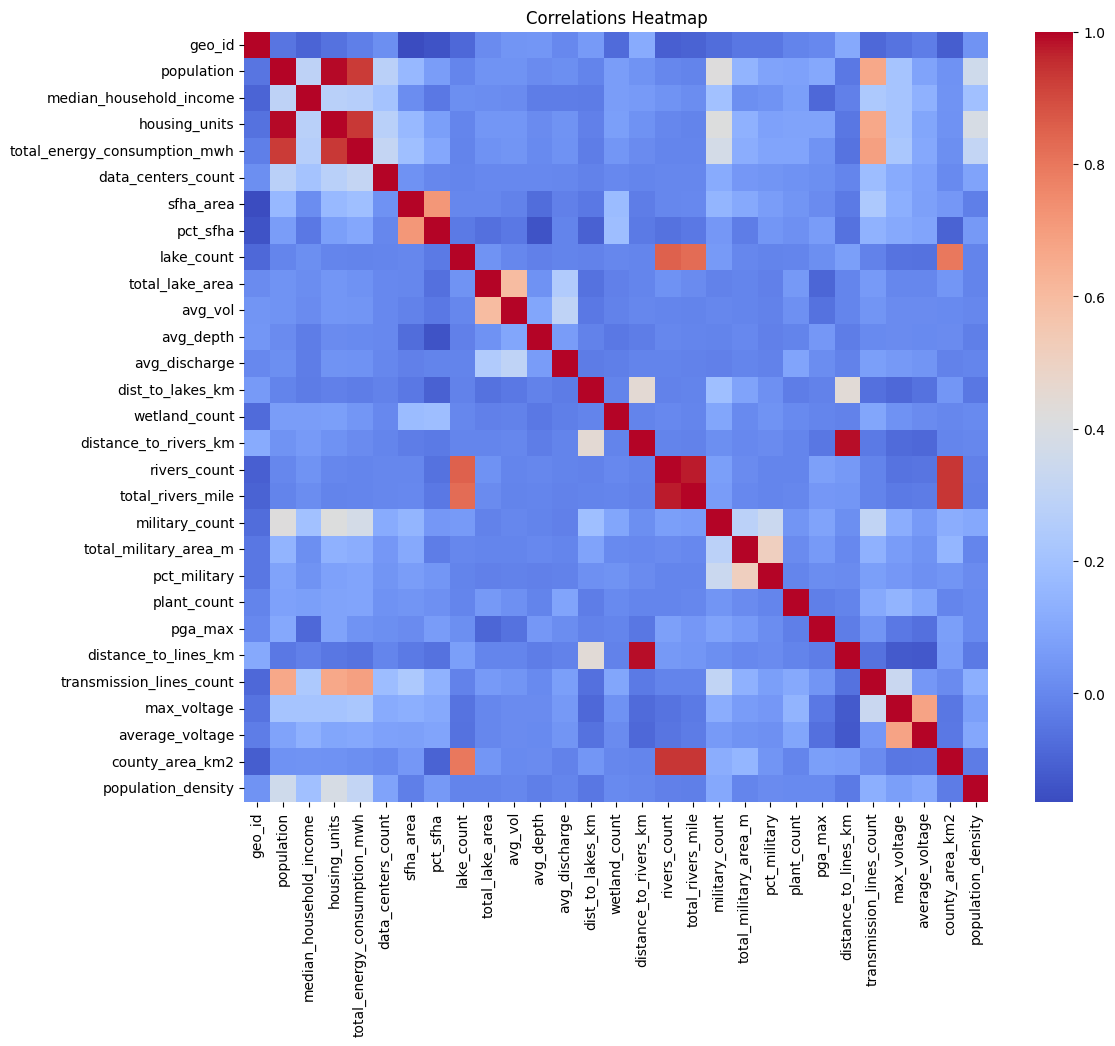

In [10]:
plt.figure(figsize=(12,10))
sns.heatmap(data=df.corr(numeric_only=True), cmap='coolwarm')
plt.title('Correlations Heatmap')
plt.savefig("../results/correlation_heatmap.png", bbox_inches = "tight")

High correlation between `housing_units` and `median_household_income`,`distance_to_lines_km` and `distance_to_rivers_km`, `total_rivers_mile` and `rivers_count`, `total_energy_consumption` and `population`, and `total_energy_consumption` and `housing_units`.

In [31]:
# sns.pairplot(df.drop(columns={'geo_id','county_name'}))

### Boxplots

In [12]:
def graph_boxplots(cols_list):
    fig, axes = plt.subplots(1, len(cols_list), figsize=(18,8))
    axes = axes.flatten()

    for i, col in enumerate(cols_list):
        axes[i].boxplot(df[col].dropna())
        axes[i].set_title(col)
        axes[i].set_xticks([])   

    plt.suptitle('Boxplots')
    plt.tight_layout()
    plt.show()

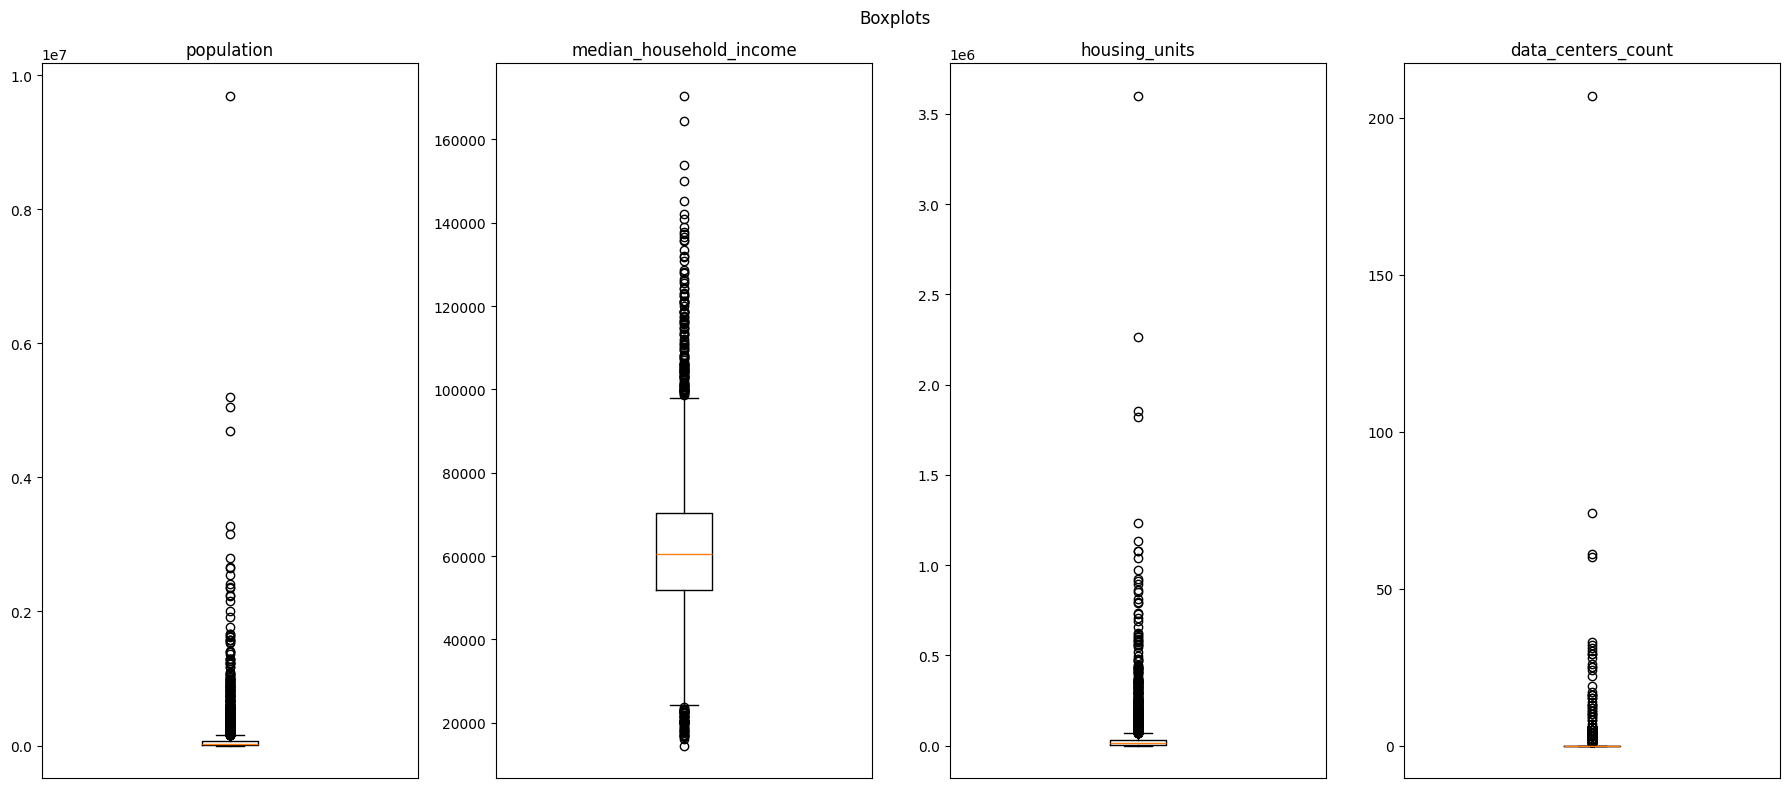

In [13]:
boxplot_cols = ['population', 'median_household_income', 'housing_units', 'data_centers_count']
graph_boxplots(boxplot_cols)

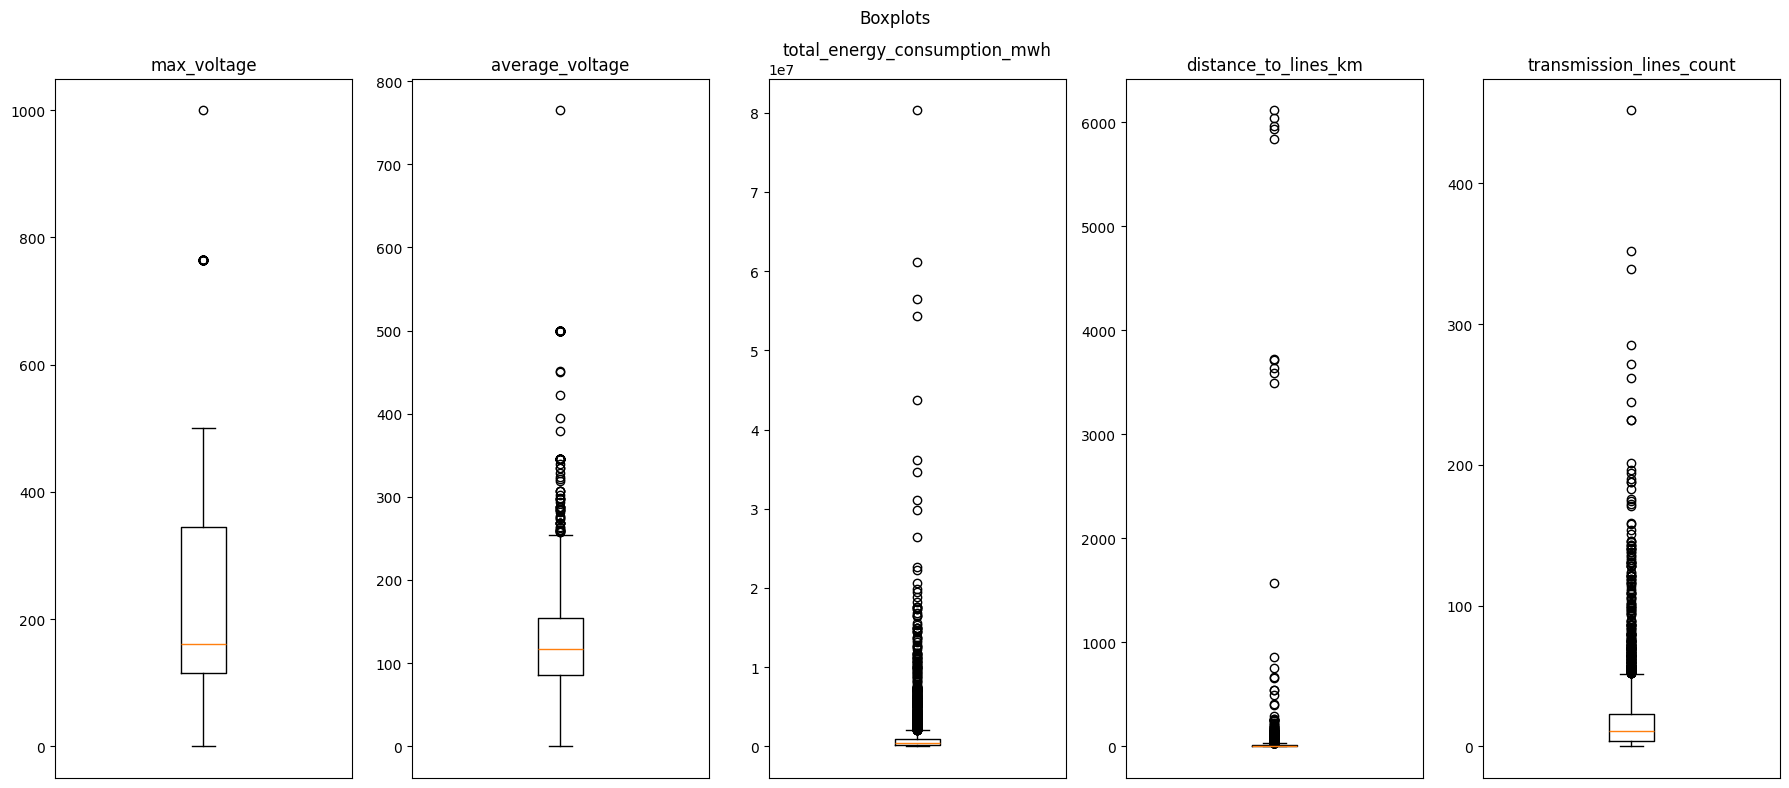

In [14]:
boxplot_cols = ['max_voltage', 'average_voltage', 'total_energy_consumption_mwh', 'distance_to_lines_km', 'transmission_lines_count']
graph_boxplots(boxplot_cols)

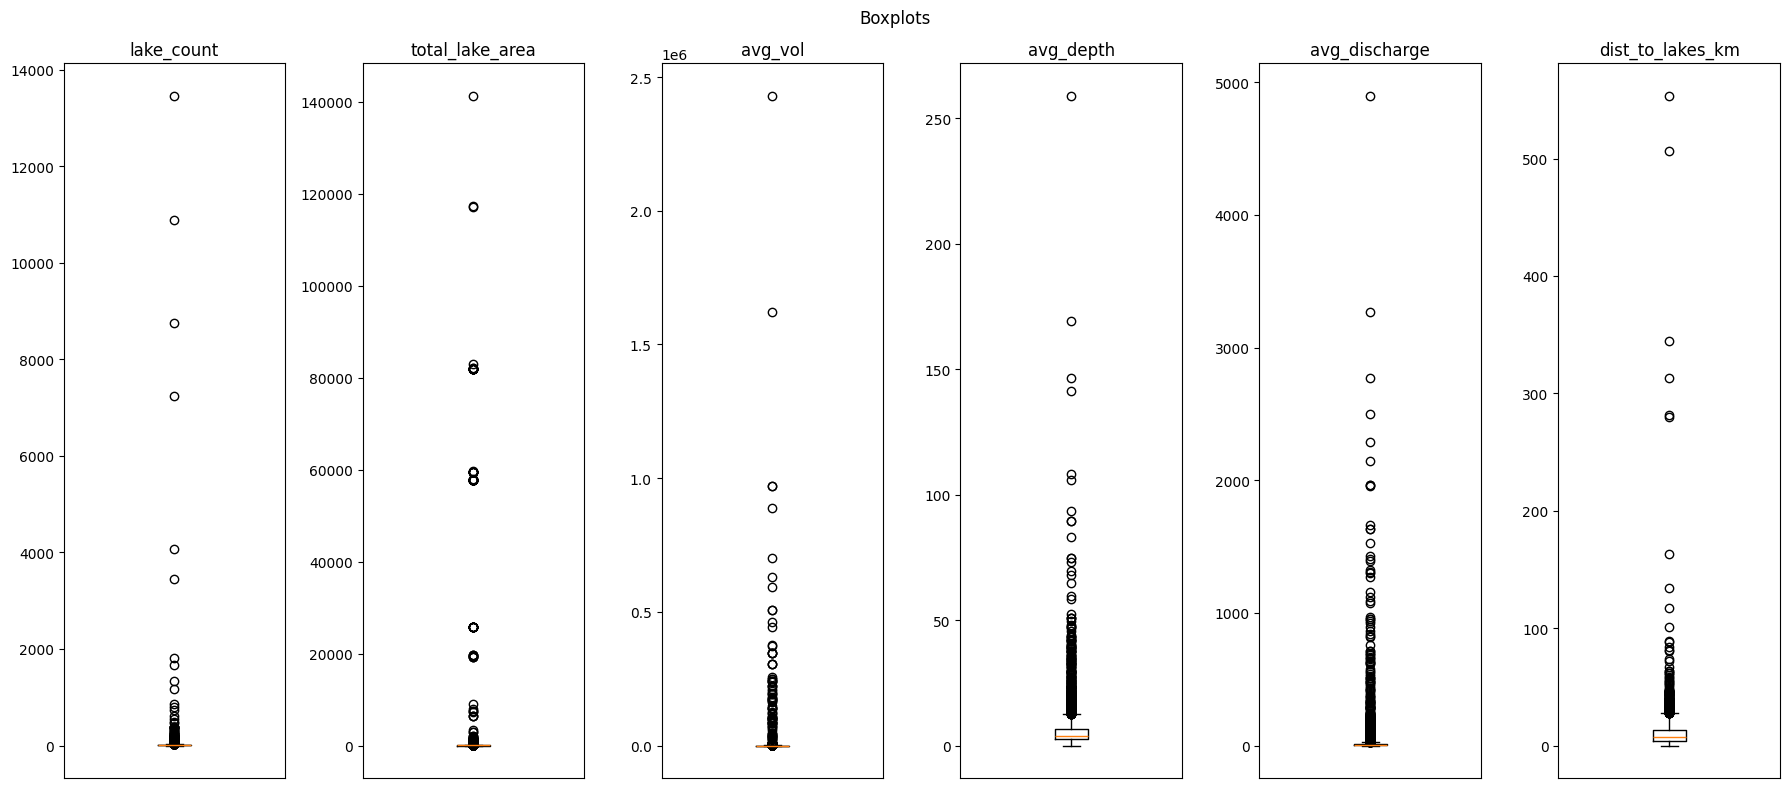

In [15]:
boxplot_cols = ['lake_count', 'total_lake_area', 'avg_vol', 'avg_depth', 'avg_discharge', 'dist_to_lakes_km']
graph_boxplots(boxplot_cols)

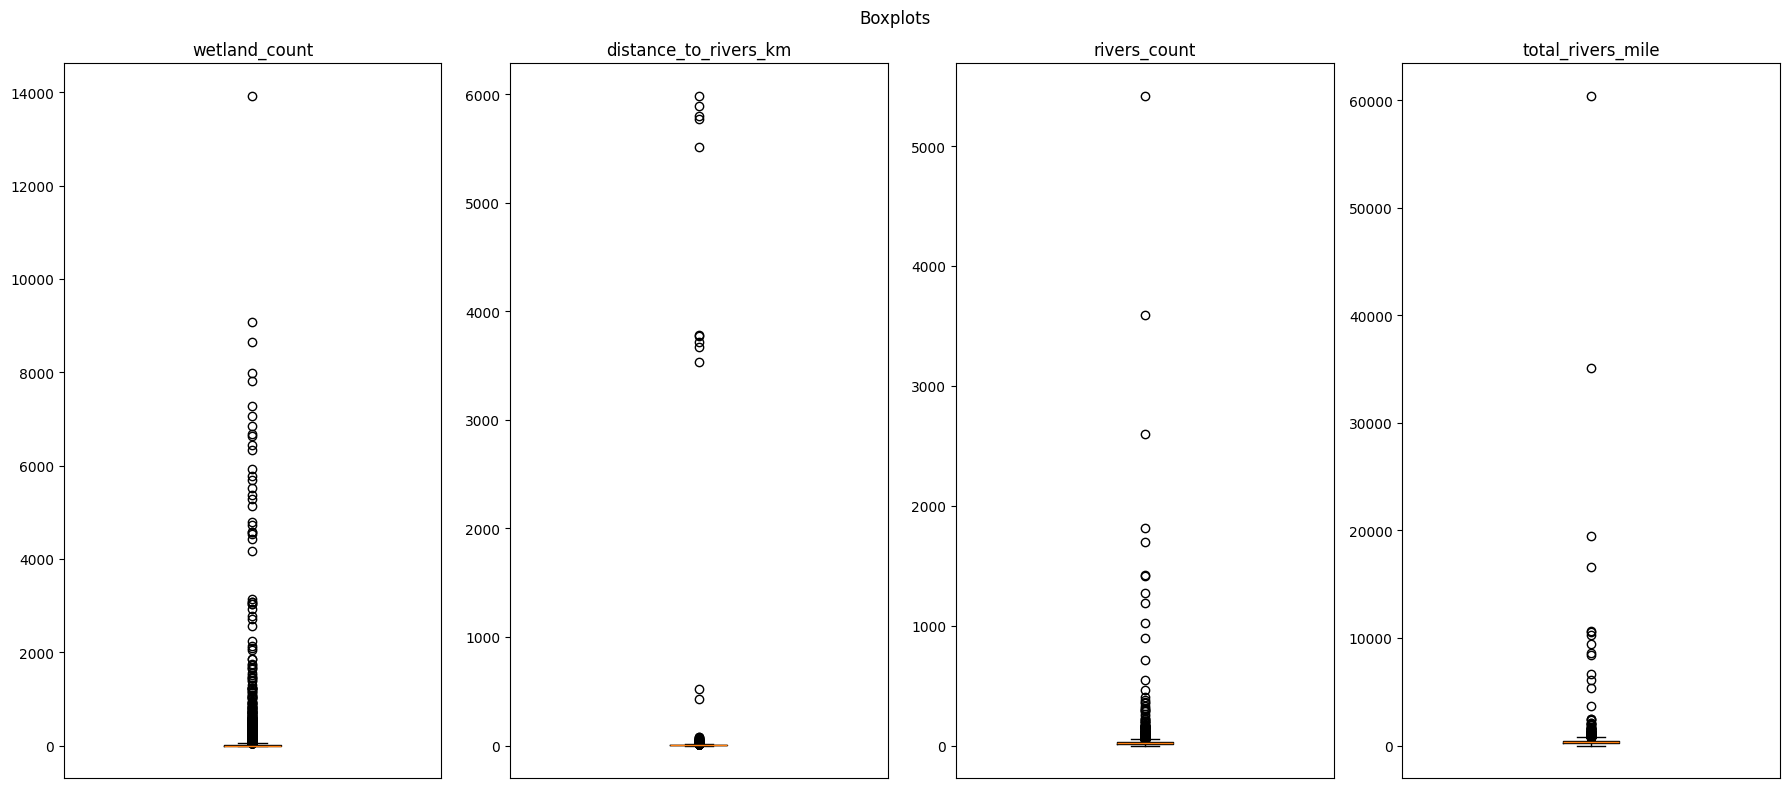

In [16]:
boxplot_cols = ['wetland_count', 'distance_to_rivers_km', 'rivers_count', 'total_rivers_mile']
graph_boxplots(boxplot_cols)

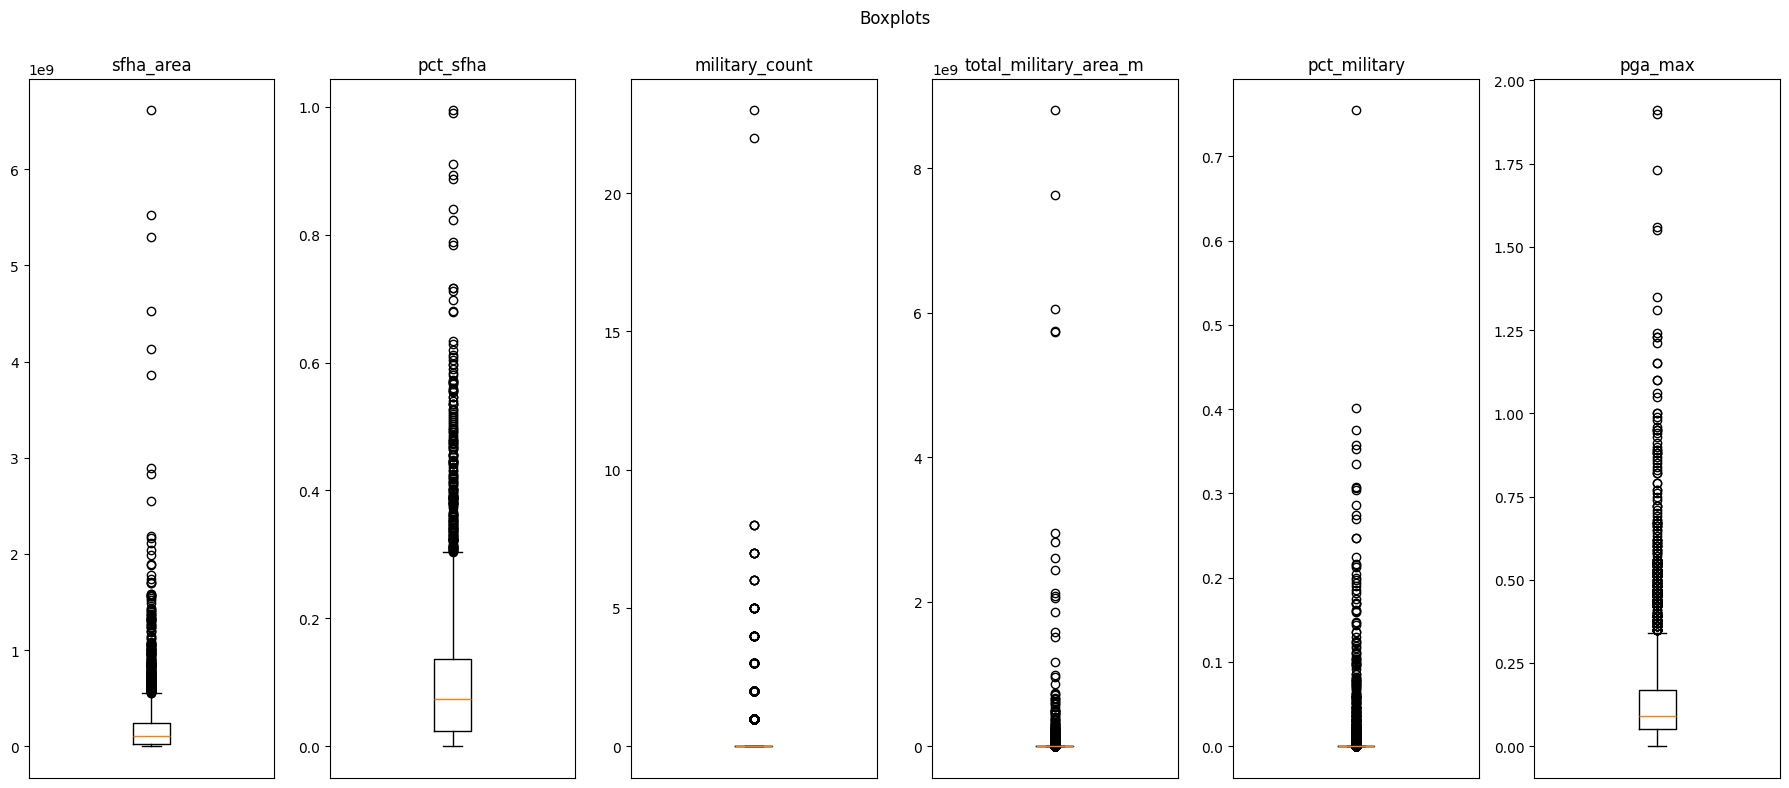

In [17]:
boxplot_cols = ['sfha_area', 'pct_sfha', 'military_count', 'total_military_area_m', 'pct_military', 'pga_max']
graph_boxplots(boxplot_cols)

### Comparison with existing nuclear plant sites

In [18]:
# comparing mean of numerical columns between counties with and without existing nuclear power plants
has_plant = df[df['plant_count'] > 0]
no_plant = df[df['plant_count'] == 0]

numerical_cols = df.select_dtypes(include='number').drop(columns={'geo_id','plant_count'}).columns

mean_comparison = pd.DataFrame({'no_plant_mean': no_plant[numerical_cols].mean(),
                                'has_plant_mean': has_plant[numerical_cols].mean()})
mean_comparison['difference_pct'] = ((mean_comparison['has_plant_mean'] - mean_comparison['no_plant_mean']) / 
                                     mean_comparison['no_plant_mean'] * 100).round(2)

mean_comparison.sort_values('difference_pct', ascending=False, inplace=True)
mean_comparison

,no_plant_mean,has_plant_mean,difference_pct
avg_discharge,3.657505e+01,1.773781e+02,384.97
total_lake_area,1.434480e+03,5.441002e+03,279.30
data_centers_count,4.181075e-01,1.518519e+00,263.19
avg_vol,6.626080e+03,2.146303e+04,223.92
total_energy_consumption_mwh,1.202634e+06,3.804016e+06,216.31
population,1.048872e+05,3.274680e+05,212.21
housing_units,4.275424e+04,1.307652e+05,205.85
transmission_lines_count,1.870072e+01,4.266667e+01,128.16
military_count,2.763282e-01,5.925926e-01,114.45
total_military_area_m,2.756033e+07,5.895384e+07,113.91


A few extreme outliers of existing plants can pull the median, trying median of numerical columns.

In [19]:
# comparing median of numerical columns
median_comparison = pd.DataFrame({'no_plant_mean': no_plant[numerical_cols].median(),
                                'has_plant_mean': has_plant[numerical_cols].median()})
median_comparison['difference_pct'] = ((median_comparison['has_plant_mean'] - median_comparison['no_plant_mean']) / 
                                     median_comparison['no_plant_mean'] * 100).round(2)

median_comparison.sort_values('difference_pct', ascending=False, inplace=True)
median_comparison

,no_plant_mean,has_plant_mean,difference_pct
avg_vol,3.260000e+00,1.523150e+01,367.22
total_lake_area,6.310000e+00,2.542500e+01,302.93
population,2.590800e+04,1.011285e+05,290.34
housing_units,1.215700e+04,4.244500e+04,249.14
total_energy_consumption_mwh,3.562655e+05,1.150671e+06,222.98
population_density,1.604078e+01,4.824807e+01,200.78
avg_discharge,9.880000e-01,2.594500e+00,162.60
transmission_lines_count,1.100000e+01,2.850000e+01,159.09
lake_count,5.000000e+00,1.150000e+01,130.00
max_voltage,1.610000e+02,3.450000e+02,114.29


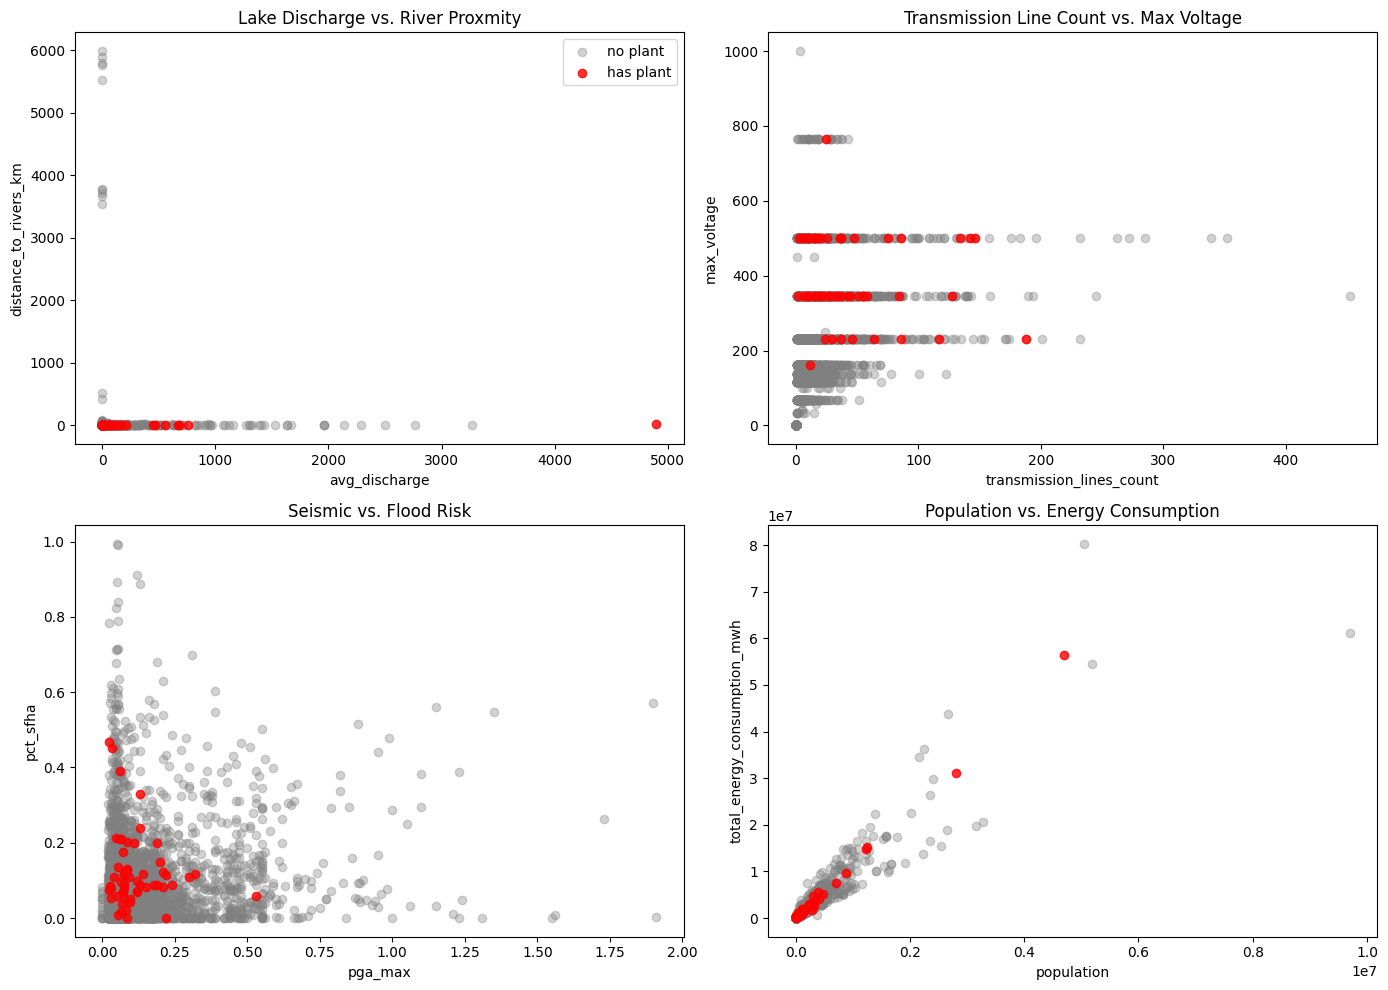

In [20]:
# scatterplots
scatter_vars = [('avg_discharge', 'distance_to_rivers_km', 'Lake Discharge vs. River Proxmity'),
                ('transmission_lines_count', 'max_voltage', 'Transmission Line Count vs. Max Voltage'),
                ('pga_max', 'pct_sfha', 'Seismic vs. Flood Risk'),
                ('population', 'total_energy_consumption_mwh', 'Population vs. Energy Consumption')]

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()
for i, (x, y, title) in enumerate(scatter_vars):
    ax = axes[i]
    ax.scatter(no_plant[x], no_plant[y], color='gray', alpha=0.35, label='no plant')
    ax.scatter(has_plant[x], has_plant[y], color='red', alpha=0.8, label='has plant')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)
axes[0].legend()
# plt.suptitle('')
plt.tight_layout()
plt.savefig("../results/with_vs_without_plants1.png", bbox_inches = "tight")

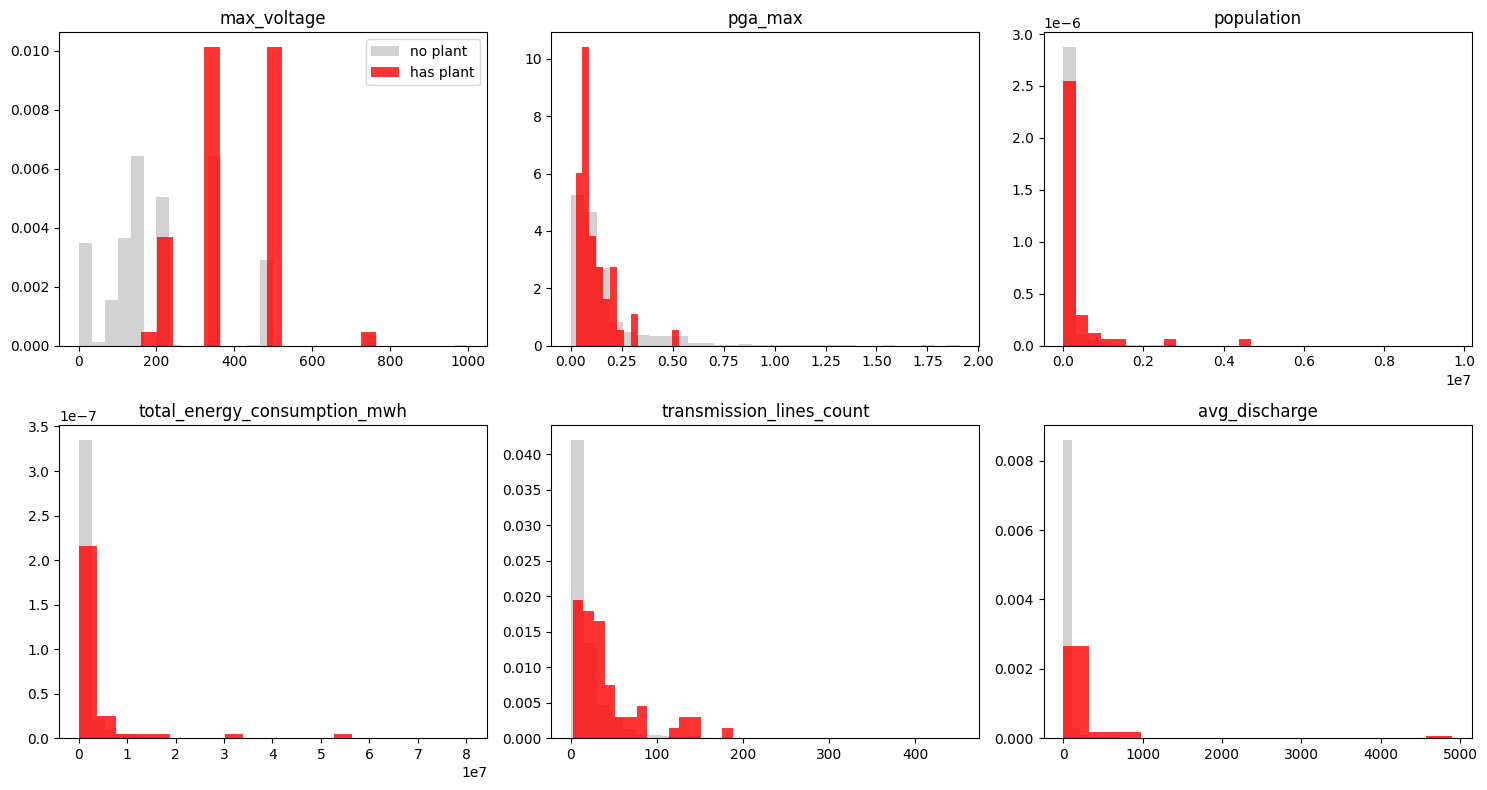

In [21]:
# histograms
hist_vars = ['max_voltage', 'pga_max', 'population', 'total_energy_consumption_mwh',
             'transmission_lines_count', 'avg_discharge']
fig, axes = plt.subplots(2,3, figsize=(15,8))
axes = axes.flatten()
for i, col in enumerate(hist_vars):
    ax = axes[i]
    ax.hist(no_plant[col], bins=30, color='gray', alpha=0.35, label='no plant', density=True)
    ax.hist(has_plant[col], bins=15, color='red', alpha=0.8, label='has plant', density=True)
    ax.set_title(col)
axes[0].legend()
plt.tight_layout()
plt.savefig("../results/with_vs_without_plants2.png", bbox_inches = "tight")

### Dropping Multicollinear Variables

In [41]:
# using VIF
df_vif = df[numerical_cols].fillna(0)
vif = pd.DataFrame({'feature': numerical_cols, 'VIF': [variance_inflation_factor(df_vif.values, i) for i in range(len(numerical_cols))]})
vif.sort_values('VIF', ascending=False, inplace=True)
vif

,feature,VIF
2,housing_units,93.978130
0,population,92.615012
21,distance_to_lines_km,53.711518
14,distance_to_rivers_km,53.413496
15,rivers_count,25.065336
16,total_rivers_mile,21.745887
3,total_energy_consumption_mwh,9.548115
24,average_voltage,7.137086
23,max_voltage,7.122923
1,median_household_income,5.600502


**Findings from correlation matrix:**

High correlation between `housing_units` and `median_household_income`,`distance_to_lines_km` and `distance_to_rivers_km`, `total_rivers_mile` and `rivers_count`, `total_energy_consumption` and `population`, and `total_energy_consumption` and `housing_units`.

**Findings from VIF:**

High correlation between `housing_units` and `population`, `distance_to_lines` and `distance_to_rivers_km`, and `rivers_count` and `total_rivers_mile`.

Moderate multicollinearity: `total_energy_consumption_mwh`, `max_voltage`, `average_voltage`, and `median_household_income`.